In [1]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain.messages import RemoveMessage,AIMessage,HumanMessage

In [2]:
load_dotenv()

True

In [3]:
llm=ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.5,
)

In [4]:
def chat(state : MessagesState):
    response=llm.invoke(state['messages'])
    return {"messages":response}

def delete_old_messages(state:  MessagesState):
    msgs=state['messages']
     
    if(len(msgs)>10):
        to_remove=msgs[:6]

        return {"messages":[RemoveMessage(id=m.id) for m in to_remove]}
    
    return {}


In [5]:
builder=StateGraph( MessagesState)
builder.add_node("chat",chat)
builder.add_node("cleanup",delete_old_messages)

builder.add_edge(START,"chat")
builder.add_edge('chat','cleanup')
builder.add_edge('cleanup',END)



In [6]:
config={"configurable":{"thread_id":":thread1"}}

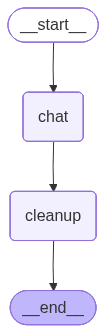

In [7]:
graph=builder.compile(checkpointer=InMemorySaver())
graph

In [8]:
graph.invoke({"messages":[{"role":'user',"content":"Hi Im nitin"}]},config)
graph.invoke({"messages":[{"role":'user',"content":"whats the weather today in gharoli delhi"}]},config)
graph.invoke({"messages":[{"role":'user',"content":"i want to learn gen ai tell mw aht is it "}]},config)
graph.invoke({"messages":[{"role":'user',"content":"whats mern stack"}]},config)
graph.invoke({"messages":[{"role":'user',"content":"how to learn it "}]},config)
graph.invoke({"messages":[{"role":'user',"content":"how will it integrate when i make ai projects using langchain and langgraph"}]},config)
graph.invoke({"messages":[{"role":'user',"content":"should i do along with development as well??"}]},config)

{'messages': [HumanMessage(content='whats mern stack', additional_kwargs={}, response_metadata={}, id='1cd0c49a-0b8a-4cfa-8175-3774102e2186'),
  AIMessage(content="**Introduction to MERN Stack**\n\nThe MERN stack is a popular web development framework that consists of four main components:\n\n1. **M** - MongoDB (NoSQL database)\n2. **E** - Express.js (Node.js web framework)\n3. **R** - React.js (Frontend JavaScript library)\n4. **N** - Node.js (JavaScript runtime environment)\n\n**Overview of Each Component:**\n\n1. **MongoDB**: A NoSQL database that stores data in a JSON-like format, allowing for flexible and scalable data storage.\n2. **Express.js**: A Node.js web framework that provides a lightweight and flexible way to build web applications, handling requests and responses.\n3. **React.js**: A frontend JavaScript library that allows for building reusable UI components, managing state, and handling user interactions.\n4. **Node.js**: A JavaScript runtime environment that allows for

In [9]:
snap=graph.get_state(config)
print(len(snap.values["messages"]))

8
